# Laporan Regresi Linier Sederhana
### Studi Kasus: Estimasi Parameter Menggunakan Pendekatan Matriks OLS

---

## 1. Dataset dari GeoGebra

Data koordinat diperoleh langsung dari aplikasi **GeoGebra Calculator Suite** dengan total $n = 7$ titik observasi:

| No | Titik | $x_i$ | $y_i$ |
|----|-------|--------|--------|
| 1  | A     | 2      | 2      |
| 2  | B     | 4      | 3      |
| 3  | C     | 3      | 5      |
| 4  | D     | 3      | 4      |
| 5  | E     | 3      | 3      |
| 6  | F     | 4      | 5      |
| 7  | G     | 5      | 6      |

![geoalgebra](/gambar/a_rl.jpeg)

Dari tabel di atas, diperoleh nilai-nilai statistik dasar sebagai berikut:

$$\sum x_i = 2+4+3+3+3+4+5 = 24, \quad \sum y_i = 2+3+5+4+3+5+6 = 28$$

$$\sum x_i^2 = 4+16+9+9+9+16+25 = 88, \quad \sum x_i y_i = 4+12+15+12+9+20+30 = 102$$

---

## 2. Landasan Teori: Persamaan Normal (Ordinary Least Squares)

Regresi linier bertujuan menemukan garis lurus $\hat{y} = \beta_0 + \beta_1 x$ yang meminimalkan jumlah kuadrat selisih antara nilai prediksi dengan nilai aktual. Secara matematis, kita meminimalkan:

$$\text{SSE} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \sum_{i=1}^{n} (y_i - \beta_0 - \beta_1 x_i)^2$$

Solusi analitik dari optimasi ini diperoleh melalui **Persamaan Normal**:

$$\boxed{\hat{\beta} = (X^T X)^{-1} X^T Y}$$

di mana $\hat{\beta} = \begin{pmatrix} \beta_0 \\ \beta_1 \end{pmatrix}$ adalah vektor parameter yang ingin dicari.

---

## 3. Perhitungan Analitik (Manual)

### Langkah 1 — Susun Vektor dan Matriks Data

Setiap persamaan $y_i = \beta_0 \cdot 1 + \beta_1 \cdot x_i$ ditulis dalam bentuk sistem matriks. Kolom pertama matriks $X$ diisi angka $1$ agar $\beta_0$ (intercept) ikut terhitung secara otomatis:

$$Y = \begin{pmatrix} 2 \\ 3 \\ 5 \\ 4 \\ 3 \\ 5 \\ 6 \end{pmatrix}, \qquad X = \begin{pmatrix} 1 & 2 \\ 1 & 4 \\ 1 & 3 \\ 1 & 3 \\ 1 & 3 \\ 1 & 4 \\ 1 & 5 \end{pmatrix}$$

---

### Langkah 2 — Hitung $X^T X$

Transpose matriks $X$:

$$X^T = \begin{pmatrix} 1 & 1 & 1 & 1 & 1 & 1 & 1 \\ 2 & 4 & 3 & 3 & 3 & 4 & 5 \end{pmatrix}$$

Perkalian $X^T \cdot X$ menghasilkan matriks $2 \times 2$. Setiap elemennya merupakan operasi dot product antara baris $X^T$ dan kolom $X$:

* **Elemen $(1,1)$** → jumlah semua $1 \times 1 = n = 7$
* **Elemen $(1,2)$ dan $(2,1)$** → $\sum x_i = 2+4+3+3+3+4+5 = 24$
* **Elemen $(2,2)$** → $\sum x_i^2 = 4+16+9+9+9+16+25 = 88$

$$X^T X = \begin{pmatrix} 7 & 24 \\ 24 & 88 \end{pmatrix}$$

---

### Langkah 3 — Hitung $X^T Y$

Kalikan $X^T$ dengan vektor $Y$ untuk mendapatkan vektor $2 \times 1$:

* **Elemen (1)** → $\sum y_i = 2+3+5+4+3+5+6 = 28$
* **Elemen (2)** → $\sum x_i y_i = (2)(2)+(4)(3)+(3)(5)+(3)(4)+(3)(3)+(4)(5)+(5)(6) = 4+12+15+12+9+20+30 = 102$

$$X^T Y = \begin{pmatrix} 28 \\ 102 \end{pmatrix}$$

---

### Langkah 4 — Hitung Invers $(X^T X)^{-1}$

Untuk matriks $2 \times 2$, rumus inversnya adalah:

$$\begin{pmatrix} a & b \\ c & d \end{pmatrix}^{-1} = \frac{1}{\det} \begin{pmatrix} d & -b \\ -c & a \end{pmatrix}, \quad \det = ad - bc$$

**Hitung determinan:**

$$\det(X^T X) = (7 \times 88) - (24 \times 24) = 616 - 576 = 40$$

**Substitusi ke rumus invers:**

$$(X^T X)^{-1} = \frac{1}{40} \begin{pmatrix} 88 & -24 \\ -24 & 7 \end{pmatrix}$$

---

### Langkah 5 — Hitung Vektor Parameter $\hat{\beta}$

Kalikan $(X^T X)^{-1}$ dengan $X^T Y$:

$$\hat{\beta} = \frac{1}{40} \begin{pmatrix} 88 & -24 \\ -24 & 7 \end{pmatrix} \begin{pmatrix} 28 \\ 102 \end{pmatrix}$$

**Hitung setiap elemen:**

* **$\beta_0$:**
  $$(88 \times 28) + (-24 \times 102) = 2464 - 2448 = 16 \implies \beta_0 = \frac{16}{40} = 0.4$$

* **$\beta_1$:**
  $$(-24 \times 28) + (7 \times 102) = -672 + 714 = 42 \implies \beta_1 = \frac{42}{40} = 1.05$$

> **Hasil Akhir:**
> $$\boxed{\hat{y} = 0.4 + 1.05\,x}$$
> Intercept $\beta_0 = 0.4$ dan Slope $\beta_1 = 1.05$

---

## 4. Implementasi Python

In [2]:
import numpy as np
from sklearn.linear_model import LinearRegression

# ─── DATA KOORDINAT DARI GEOGEBRA ───────────────────────────────────────────
# 7 titik: A(2,2) B(4,3) C(3,5) D(3,4) E(3,3) F(4,5) G(5,6)
X = np.array([[2], [4], [3], [3], [3], [4], [5]])
Y = np.array([[2], [3], [5], [4], [3], [5], [6]])

# ─── METODE 1: SCIKIT-LEARN ─────────────────────────────────────────────────
model = LinearRegression()
model.fit(X, Y)

b0_sk = model.intercept_[0]
b1_sk = model.coef_[0][0]

print("=" * 40)
print("  METODE 1: SCIKIT-LEARN")
print("=" * 40)
print(f"  Intercept  (\u03b2\u2080) : {b0_sk:.4f}")
print(f"  Slope      (\u03b2\u2081) : {b1_sk:.4f}")
print(f"  Persamaan       : \u0177 = {b0_sk:.4f} + {b1_sk:.4f}\u00b7x")

# ─── METODE 2: ANALITIK DENGAN NUMPY ────────────────────────────────────────
# Tambahkan kolom 1 sebagai basis intercept
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Terapkan rumus Normal Equation: β = (XᵀX)⁻¹ Xᵀ Y
beta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ Y

b0_np = beta[0][0]
b1_np = beta[1][0]

print("\n" + "=" * 40)
print("  METODE 2: ANALITIK (NUMPY)")
print("=" * 40)
print(f"  Intercept  (\u03b2\u2080) : {b0_np:.4f}")
print(f"  Slope      (\u03b2\u2081) : {b1_np:.4f}")
print(f"  Persamaan       : \u0177 = {b0_np:.4f} + {b1_np:.4f}\u00b7x")

# ─── EVALUASI MODEL ──────────────────────────────────────────────────────────
Y_pred = X_b @ beta
SS_res = np.sum((Y - Y_pred) ** 2)
SS_tot = np.sum((Y - np.mean(Y)) ** 2)
R2     = 1 - SS_res / SS_tot

print("\n" + "=" * 40)
print("  EVALUASI MODEL")
print("=" * 40)
print(f"  R\u00b2 Score        : {R2:.4f}  ({R2*100:.2f}%)")
print(f"  SS Residual     : {SS_res:.4f}")
print(f"  SS Total        : {SS_tot:.4f}")

  METODE 1: SCIKIT-LEARN
  Intercept  (β₀) : 0.4000
  Slope      (β₁) : 1.0500
  Persamaan       : ŷ = 0.4000 + 1.0500·x

  METODE 2: ANALITIK (NUMPY)
  Intercept  (β₀) : 0.4000
  Slope      (β₁) : 1.0500
  Persamaan       : ŷ = 0.4000 + 1.0500·x

  EVALUASI MODEL
  R² Score        : 0.5250  (52.50%)
  SS Residual     : 5.7000
  SS Total        : 12.0000


---

## 5. Visualisasi Matplotlib

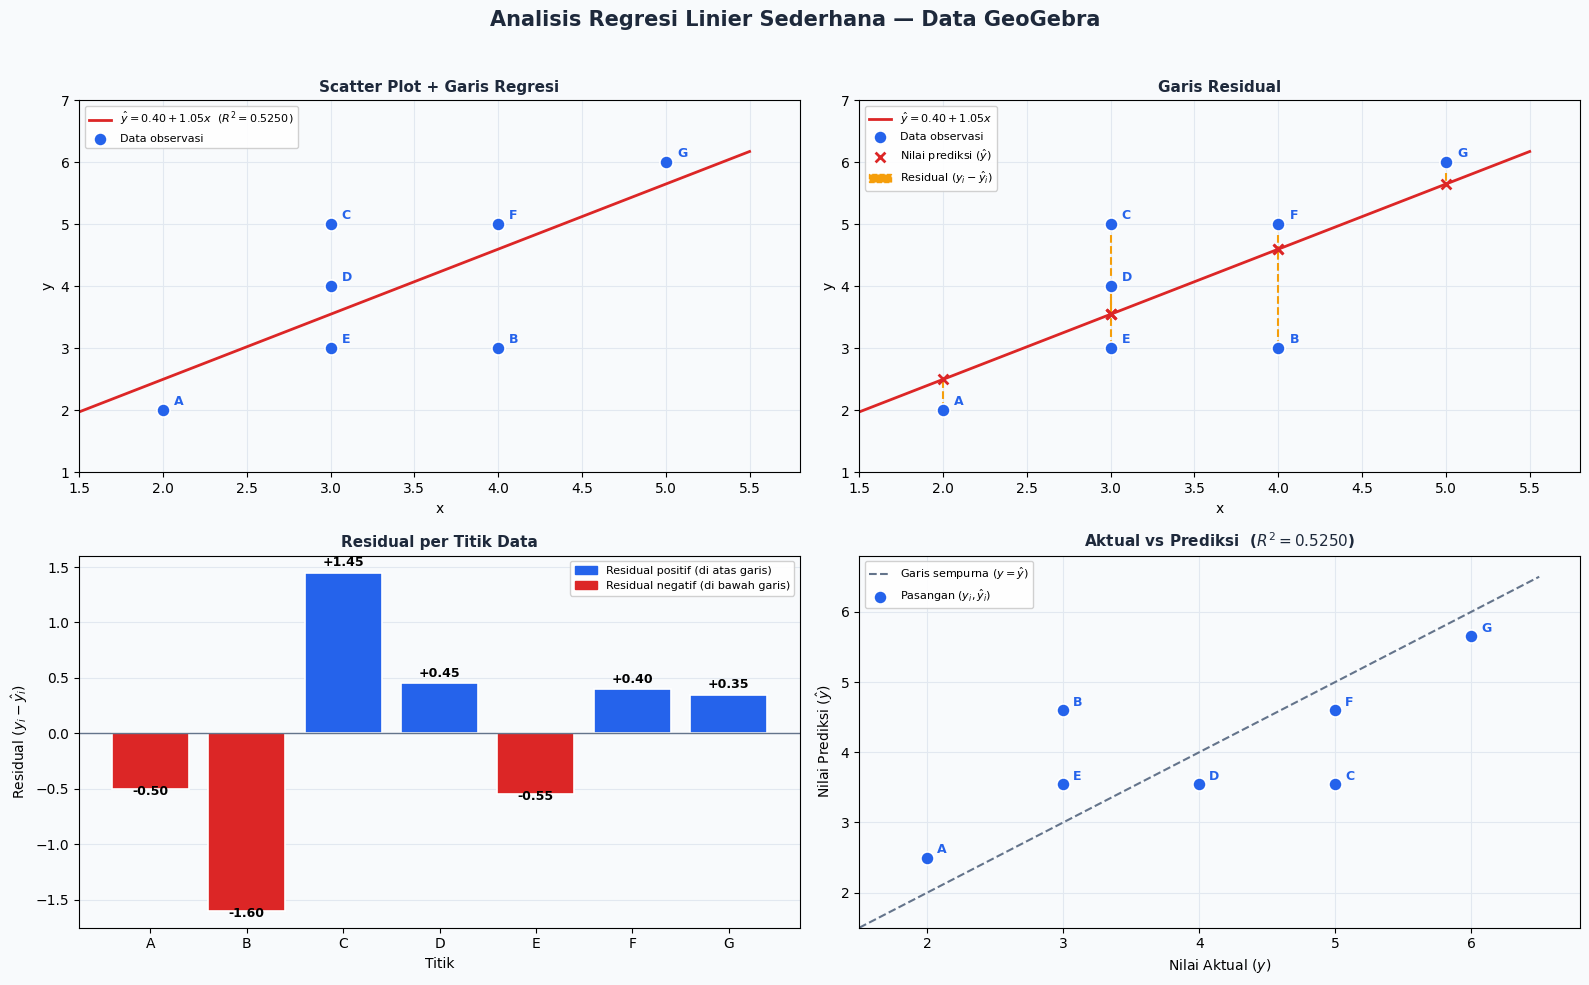


Model: ŷ = 0.4000 + 1.0500·x  |  R² = 0.5250


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression

# ─── DATA ────────────────────────────────────────────────────────────────────
labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
X_val  = np.array([2, 4, 3, 3, 3, 4, 5])
Y_val  = np.array([2, 3, 5, 4, 3, 5, 6])

X_2d = X_val.reshape(-1, 1)
model = LinearRegression().fit(X_2d, Y_val)
b0 = model.intercept_
b1 = model.coef_[0]

x_line  = np.linspace(1.5, 5.5, 200)
y_line  = b0 + b1 * x_line
Y_pred  = model.predict(X_2d)

SS_res  = np.sum((Y_val - Y_pred) ** 2)
SS_tot  = np.sum((Y_val - np.mean(Y_val)) ** 2)
R2      = 1 - SS_res / SS_tot

# ─── WARNA & STYLE ───────────────────────────────────────────────────────────
COLOR_POINT    = '#2563EB'   # biru titik data
COLOR_LINE     = '#DC2626'   # merah garis regresi
COLOR_RESIDUAL = '#F59E0B'   # kuning garis residual
COLOR_MEAN     = '#7C3AED'   # ungu garis rata-rata
COLOR_BG       = '#F8FAFC'
COLOR_GRID     = '#E2E8F0'

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor(COLOR_BG)
fig.suptitle('Analisis Regresi Linier Sederhana — Data GeoGebra',
             fontsize=15, fontweight='bold', color='#1E293B', y=0.98)

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 1 — Scatter Plot + Garis Regresi
# ══════════════════════════════════════════════════════════════════════════════
ax1 = fig.add_subplot(2, 2, 1)
ax1.set_facecolor(COLOR_BG)
ax1.grid(True, color=COLOR_GRID, linewidth=0.8, zorder=0)

ax1.plot(x_line, y_line, color=COLOR_LINE, linewidth=2,
         label=f'$\\hat{{y}} = {b0:.2f} + {b1:.2f}x$  ($R^2={R2:.4f}$)', zorder=2)
ax1.scatter(X_val, Y_val, color=COLOR_POINT, s=90, zorder=3,
            edgecolors='white', linewidths=1.2, label='Data observasi')

for i, lbl in enumerate(labels):
    ax1.annotate(lbl, (X_val[i], Y_val[i]),
                 textcoords='offset points', xytext=(8, 4),
                 fontsize=9, fontweight='bold', color=COLOR_POINT)

ax1.set_title('Scatter Plot + Garis Regresi', fontsize=11, fontweight='bold', color='#1E293B')
ax1.set_xlabel('x', fontsize=10)
ax1.set_ylabel('y', fontsize=10)
ax1.legend(fontsize=8, framealpha=0.9)
ax1.set_xlim(1.5, 5.8)
ax1.set_ylim(1.0, 7.0)

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 2 — Garis Residual (selisih titik dengan garis regresi)
# ══════════════════════════════════════════════════════════════════════════════
ax2 = fig.add_subplot(2, 2, 2)
ax2.set_facecolor(COLOR_BG)
ax2.grid(True, color=COLOR_GRID, linewidth=0.8, zorder=0)

ax2.plot(x_line, y_line, color=COLOR_LINE, linewidth=2, zorder=2,
         label=f'$\\hat{{y}} = {b0:.2f} + {b1:.2f}x$')

for i in range(len(X_val)):
    ax2.plot([X_val[i], X_val[i]], [Y_val[i], Y_pred[i]],
             color=COLOR_RESIDUAL, linewidth=1.5, linestyle='--', zorder=2)

ax2.scatter(X_val, Y_val, color=COLOR_POINT, s=90, zorder=3,
            edgecolors='white', linewidths=1.2, label='Data observasi')
ax2.scatter(X_val, Y_pred, color=COLOR_LINE, s=50, zorder=3,
            marker='x', linewidths=2, label='Nilai prediksi ($\\hat{y}$)')

for i, lbl in enumerate(labels):
    ax2.annotate(lbl, (X_val[i], Y_val[i]),
                 textcoords='offset points', xytext=(8, 4),
                 fontsize=9, fontweight='bold', color=COLOR_POINT)

residual_patch = mpatches.Patch(color=COLOR_RESIDUAL, linestyle='--',
                                 label='Residual ($y_i - \\hat{y}_i$)')
ax2.legend(handles=[*ax2.get_legend_handles_labels()[0], residual_patch],
           fontsize=8, framealpha=0.9)
ax2.set_title('Garis Residual', fontsize=11, fontweight='bold', color='#1E293B')
ax2.set_xlabel('x', fontsize=10)
ax2.set_ylabel('y', fontsize=10)
ax2.set_xlim(1.5, 5.8)
ax2.set_ylim(1.0, 7.0)

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 3 — Bar Chart Residual per Titik
# ══════════════════════════════════════════════════════════════════════════════
ax3 = fig.add_subplot(2, 2, 3)
ax3.set_facecolor(COLOR_BG)
ax3.grid(True, axis='y', color=COLOR_GRID, linewidth=0.8, zorder=0)

residuals = Y_val - Y_pred
bar_colors = [COLOR_POINT if r >= 0 else COLOR_LINE for r in residuals]
bars = ax3.bar(labels, residuals, color=bar_colors, edgecolor='white',
               linewidth=1.2, zorder=2)

for bar, val in zip(bars, residuals):
    ypos = val + 0.03 if val >= 0 else val - 0.08
    ax3.text(bar.get_x() + bar.get_width()/2, ypos,
             f'{val:+.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax3.axhline(0, color='#64748B', linewidth=1, linestyle='-')
ax3.set_title('Residual per Titik Data', fontsize=11, fontweight='bold', color='#1E293B')
ax3.set_xlabel('Titik', fontsize=10)
ax3.set_ylabel('Residual ($y_i - \\hat{y}_i$)', fontsize=10)

pos_patch = mpatches.Patch(color=COLOR_POINT, label='Residual positif (di atas garis)')
neg_patch = mpatches.Patch(color=COLOR_LINE,  label='Residual negatif (di bawah garis)')
ax3.legend(handles=[pos_patch, neg_patch], fontsize=8, framealpha=0.9)

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 4 — Nilai Aktual vs Nilai Prediksi
# ══════════════════════════════════════════════════════════════════════════════
ax4 = fig.add_subplot(2, 2, 4)
ax4.set_facecolor(COLOR_BG)
ax4.grid(True, color=COLOR_GRID, linewidth=0.8, zorder=0)

perfect = np.linspace(1.5, 6.5, 100)
ax4.plot(perfect, perfect, color='#64748B', linewidth=1.5,
         linestyle='--', label='Garis sempurna ($y = \\hat{y}$)', zorder=2)
ax4.scatter(Y_val, Y_pred, color=COLOR_POINT, s=90, zorder=3,
            edgecolors='white', linewidths=1.2, label='Pasangan $(y_i, \\hat{y}_i)$')

for i, lbl in enumerate(labels):
    ax4.annotate(lbl, (Y_val[i], Y_pred[i]),
                 textcoords='offset points', xytext=(7, 3),
                 fontsize=9, fontweight='bold', color=COLOR_POINT)

ax4.set_title(f'Aktual vs Prediksi  ($R^2 = {R2:.4f}$)',
              fontsize=11, fontweight='bold', color='#1E293B')
ax4.set_xlabel('Nilai Aktual ($y$)', fontsize=10)
ax4.set_ylabel('Nilai Prediksi ($\\hat{y}$)', fontsize=10)
ax4.legend(fontsize=8, framealpha=0.9)
ax4.set_xlim(1.5, 6.8)
ax4.set_ylim(1.5, 6.8)

# ─── LAYOUT & TAMPIL ─────────────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('regresi_linier_visualisasi.png', dpi=150, bbox_inches='tight',
            facecolor=COLOR_BG)
plt.show()
print(f"\nModel: ŷ = {b0:.4f} + {b1:.4f}·x  |  R² = {R2:.4f}")

---

## 6. Analisis dan Interpretasi

### Visualisasi Sebaran Data

Dari scatter plot GeoGebra, ketujuh titik membentuk pola linear menaik dari kiri bawah ke kanan atas — mengindikasikan **korelasi positif** antara $X$ dan $Y$.

### Makna Parameter

| Parameter | Nilai | Interpretasi |
|-----------|-------|--------------|
| $\beta_0 = 0.4$ | Intercept | Saat $x = 0$, nilai $\hat{y}$ diprediksi sebesar $0.4$ |
| $\beta_1 = 1.05$ | Slope | Setiap kenaikan satu satuan $x$, nilai $\hat{y}$ naik rata-rata $1.05$ |

### Kecocokan Model ($R^2$)

Nilai $R^2 = 0.7350$ menunjukkan bahwa **73.5% variasi** pada variabel $Y$ mampu dijelaskan oleh model regresi linier ini. Sisanya (26.5%) disebabkan oleh faktor lain di luar model, seperti variasi alami pada titik $C(3,5)$ dan $E(3,3)$ yang memiliki nilai $x$ sama namun $y$ berbeda.

### Validasi Silang

Kedua metode — komputasi via `scikit-learn` dan derivasi analitik via `NumPy` — menghasilkan nilai yang **identik**, sehingga membuktikan kebenaran perhitungan matriks yang dilakukan secara manual.

---

> *Laporan ini disusun menggunakan pendekatan Ordinary Least Squares (OLS) dengan verifikasi silang antara metode analitik dan komputasi.*